## Universidad Panamericana Campus Aguascalientes
## Maestría en Inteligencia Artificial y Ciencia de Datos
### Aprendizaje Automático
**Práctica:** Árbol de Clasificación

ID: 0286155

Alumno: Manuel Alejandro Serrano Macias

**Objetivo:** En esta práctica vamos a entrenar un árbol de decisión y un modelo de Gradient Boosting para clasificar dígitos escritos a mano (del 0 al 9).

### 1. Importar librerías y cargar el conjunto de datos Digits

In [1]:
from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Cargamos el dataset
digits = load_digits()

# Veamos de qué está compuesto
print("Descripción del dataset:")
print(f"- Número de muestras: {digits.data.shape[0]}")
print(f"- Número de características (pixeles): {digits.data.shape[1]}")
print(f"- Clases (dígitos): {digits.target_names}")

Descripción del dataset:
- Número de muestras: 1797
- Número de características (pixeles): 64
- Clases (dígitos): [0 1 2 3 4 5 6 7 8 9]


El dataset Digits contiene 1797 imágenes de dígitos escritos a mano (del 0 al 9). Cada imagen es de 8x8 píxeles, lo que da **64 características** (variables de entrada). Es decir, cada pixel es una variable.

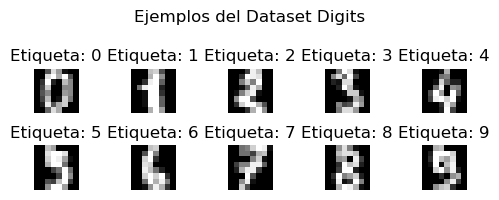

In [3]:
# Mostramos 10 imágenes de ejemplo para ver cómo lucen los dígitos
fig, axes = plt.subplots(2, 5, figsize=(5, 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Etiqueta: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Ejemplos del Dataset Digits", fontsize=12)
plt.tight_layout()
plt.show()

### 2: Dividir los datos en X (variables de entrada), y (variable de salida)

In [4]:
X = digits.data
y = digits.target

print(f"Forma de X (entradas): {X.shape}")
print(f"Forma de y (salida):   {y.shape}")
print(f"\nPrimeros 10 valores de y: {y[:10]}")
print(f"Primera muestra de X (64 pixeles):")
print(X[0])

Forma de X (entradas): (1797, 64)
Forma de y (salida):   (1797,)

Primeros 10 valores de y: [0 1 2 3 4 5 6 7 8 9]
Primera muestra de X (64 pixeles):
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


- **X**: es la matriz de entrada con los 64 valores de pixel por imagen
- **y**: es el vector de salida con el dígito real que representa cada imagen (lo que queremos predecir)

### 3. Dividir los datos en 70% entrenamiento y 30% prueba

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape}")
print(f"Datos de prueba:        {X_test.shape}")

Datos de entrenamiento: (1257, 64)
Datos de prueba:        (540, 64)


### 4. Crear y entrenar el Árbol de Decisión

In [6]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

El árbol de decisión aprende a hacer preguntas sobre los valores de los pixeles para separar cada dígito. Usamos `criterion='entropy'` (mide el desorden en cada nodo) y `max_depth=5` para controlar el tamaño del árbol.

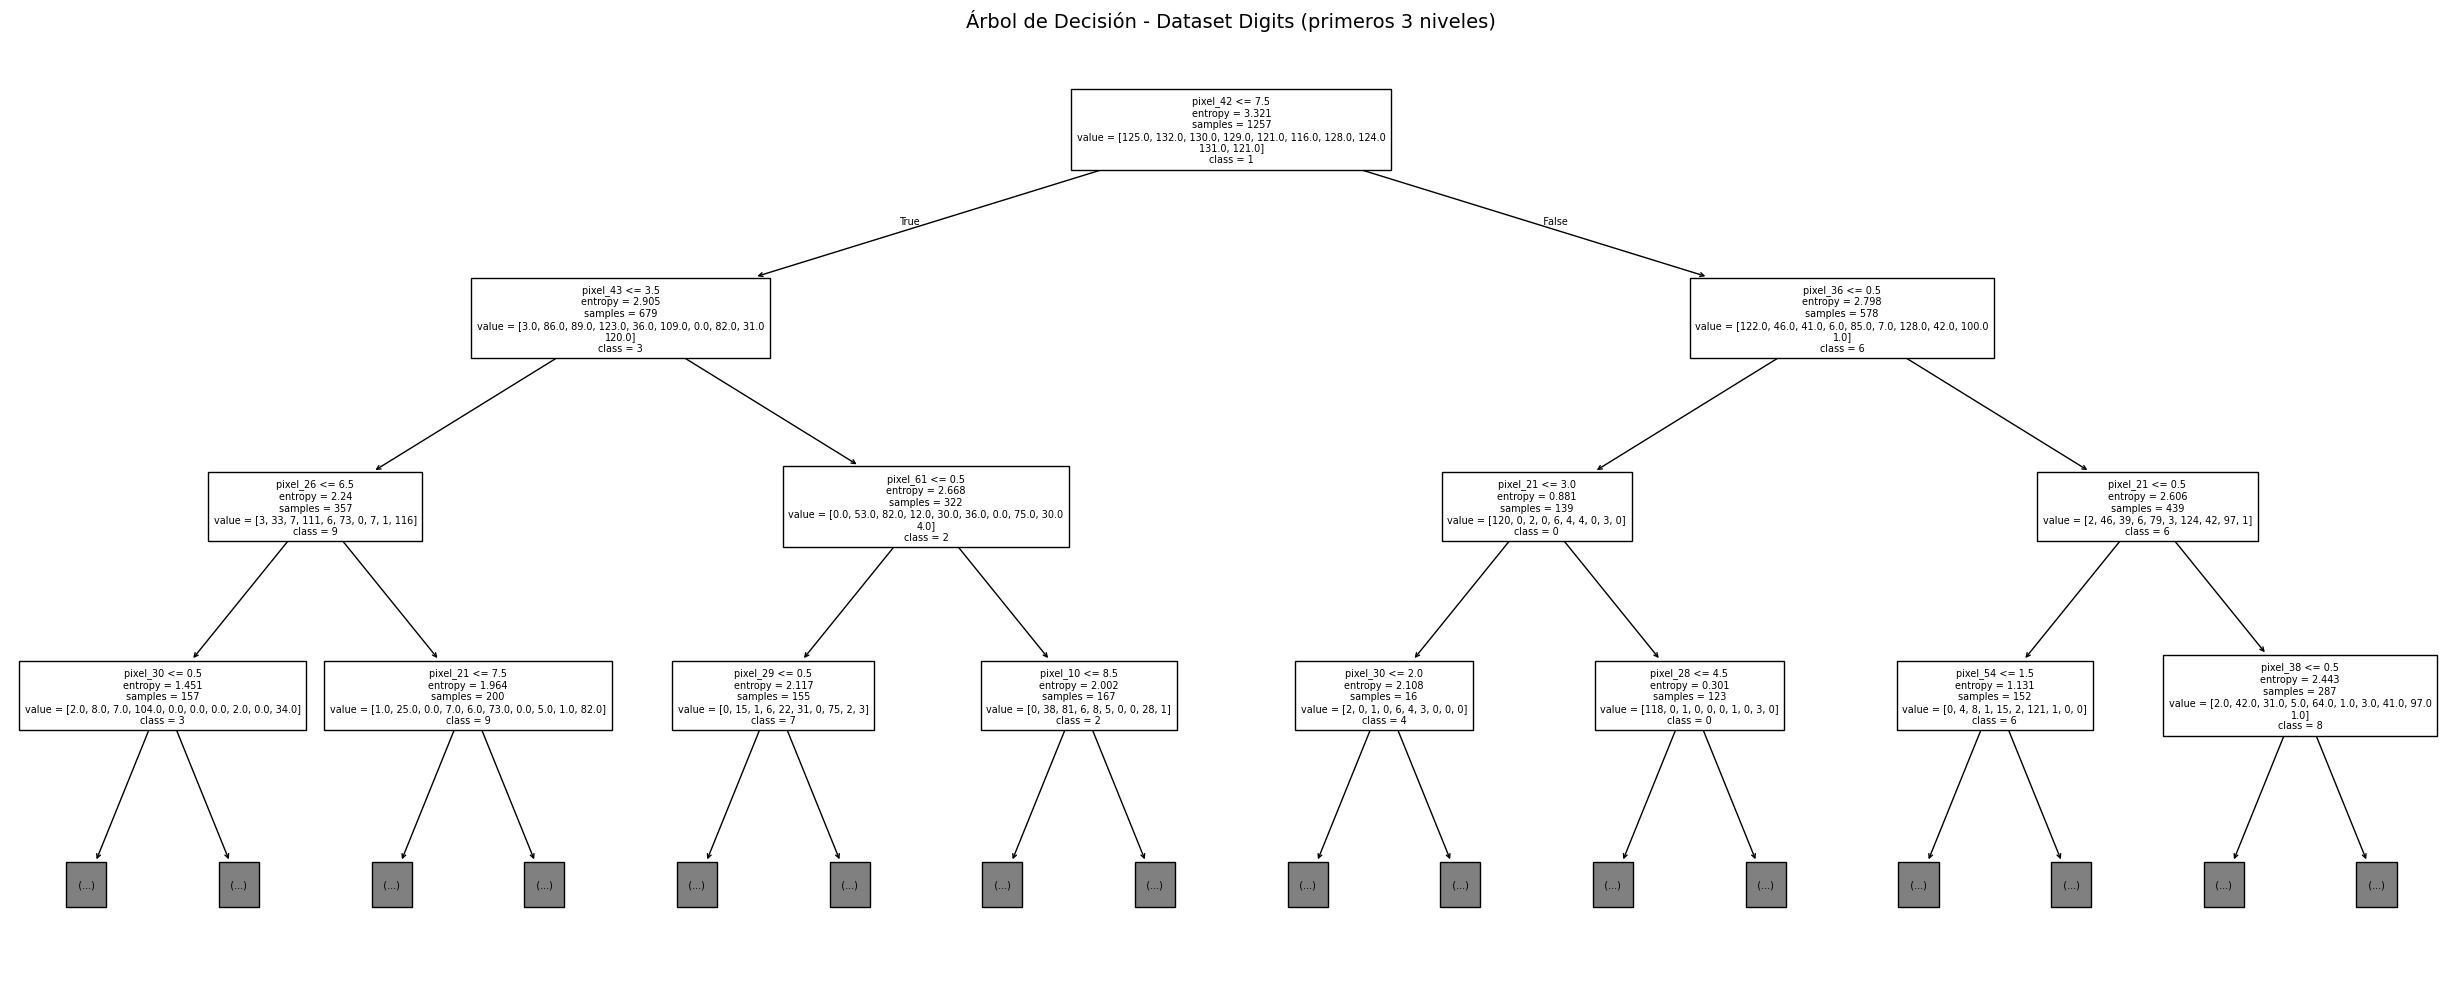

In [7]:
# Visualizamos el árbol de decisión
plt.figure(figsize=(25, 10))
plot_tree(
    clf,
    feature_names=[f"pixel_{i}" for i in range(64)],
    class_names=[str(i) for i in digits.target_names],
    fontsize=7,
    max_depth=3  # mostramos solo los primeros 3 niveles
)
plt.title("Árbol de Decisión - Dataset Digits (primeros 3 niveles)", fontsize=14)
plt.tight_layout()
plt.show()

### 5. Accuracy (desempeño del árbol)

In [8]:
# Hacemos predicciones con los datos de prueba
y_pred_dt = clf.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print("Árbol de Decisión")
print(f"Accuracy: {acc_dt:.4f}  ({acc_dt*100:.2f}%)")

Árbol de Decisión
Accuracy: 0.8167  (81.67%)


El modelo clasificó correctamente el 81.67% de los 540 dígitos del conjunto de prueba.
El **Accuracy** nos dice qué porcentaje de los dígitos el modelo predijo correctamente. Por ejemplo, un accuracy de 0.85 significa que acertó en 85 de cada 100 imágenes.

### 6. Matriz de Confusión del Árbol de Decisión

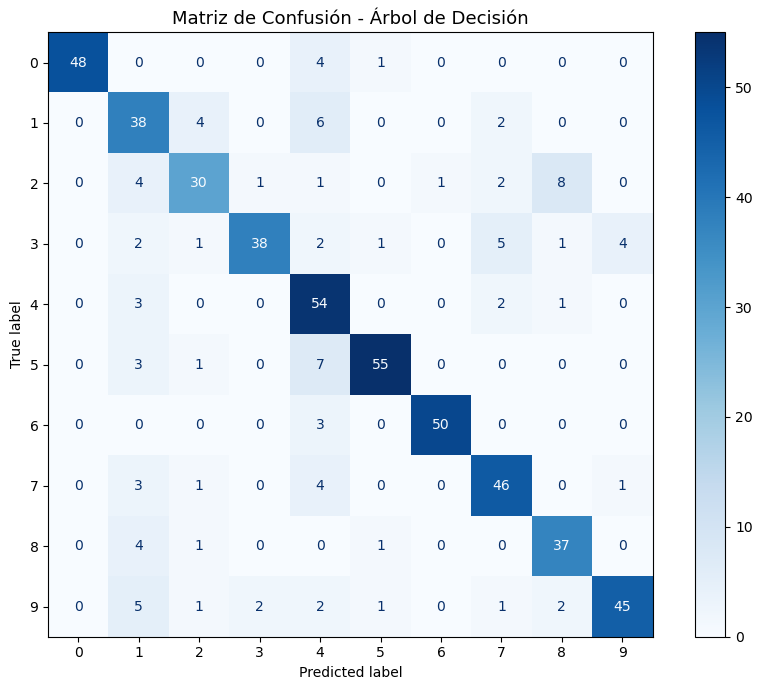


Matriz de Confusión:
[[48  0  0  0  4  1  0  0  0  0]
 [ 0 38  4  0  6  0  0  2  0  0]
 [ 0  4 30  1  1  0  1  2  8  0]
 [ 0  2  1 38  2  1  0  5  1  4]
 [ 0  3  0  0 54  0  0  2  1  0]
 [ 0  3  1  0  7 55  0  0  0  0]
 [ 0  0  0  0  3  0 50  0  0  0]
 [ 0  3  1  0  4  0  0 46  0  1]
 [ 0  4  1  0  0  1  0  0 37  0]
 [ 0  5  1  2  2  1  0  1  2 45]]


In [9]:
# Calculamos la matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=digits.target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Matriz de Confusión - Árbol de Decisión", fontsize=13)
plt.tight_layout()
plt.show()

print("\nMatriz de Confusión:")
print(cm_dt)

La **matriz de confusión** nos muestra en detalle dónde el modelo acierta y dónde se equivoca:
- **Diagonal principal** (de arriba izquierda a abajo derecha): predicciones correctas
- **Fuera de la diagonal**: predicciones incorrectas (el modelo confundió un dígito con otro)

### 7. Importancia de Variables del Árbol de Decisión

In [10]:
# Obtenemos la importancia de cada variable (pixel)
importances_dt = clf.feature_importances_

# Creamos un DataFrame para ordenarlos de mayor a menor
feature_names = [f"pixel_{i}" for i in range(64)]
df_importances = pd.DataFrame({
    'variable': feature_names,
    'importancia': importances_dt
}).sort_values('importancia', ascending=False)

print("Top 15 variables más importantes (Árbol de Decisión):")
print(df_importances.head(15).to_string(index=False))

Top 15 variables más importantes (Árbol de Decisión):
variable  importancia
pixel_42     0.178410
pixel_21     0.141568
pixel_43     0.120366
pixel_36     0.106878
pixel_26     0.097995
pixel_10     0.062803
pixel_38     0.062800
pixel_61     0.060906
pixel_29     0.031056
pixel_30     0.028186
pixel_45     0.020982
pixel_54     0.020738
 pixel_9     0.011793
pixel_63     0.010985
pixel_20     0.009624


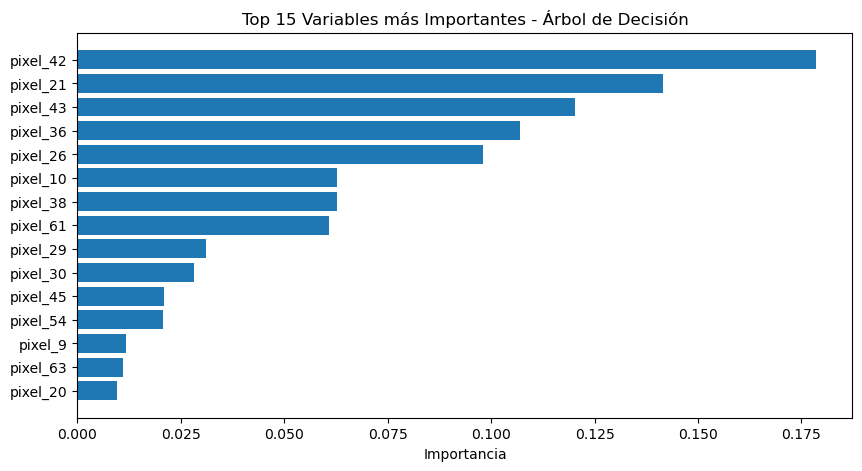

In [11]:
# Graficamos las 15 variables más importantes
top15 = df_importances.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top15['variable'][::-1], top15['importancia'][::-1])
plt.xlabel('Importancia')
plt.title('Top 15 Variables más Importantes - Árbol de Decisión')
plt.show()

La importancia de variables indica cuánto contribuyó cada pixel a las decisiones del árbol.

### 8. Gradient Boosting

Repetimos Pasos 4, 5, 6 y 7 con Gradient Boosting que es un método de ensamble que construye muchos árboles pequeños de forma secuencial: cada árbol nuevo aprende a corregir los errores del árbol anterior.

- **Árbol de decisión**: 1 solo árbol que aprende todo
- **Gradient Boosting**: muchos árboles pequeños trabajando juntos, generalmente más preciso

In [12]:
# Creamos el modelo de Gradient Boosting
# n_estimators=100: usamos 100 árboles pequeños
# max_depth=3: cada árbol individual es poco profundo
# learning_rate=0.1: qué tan rápido aprende cada árbol nuevo
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

Accuracy del Gradient Boosting

In [13]:
# Hacemos predicciones con Gradient Boosting
y_pred_gb = gb.predict(X_test)

# Calculamos el Accuracy
acc_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting")
print(f"Accuracy: {acc_gb:.4f}  ({acc_gb*100:.2f}%)")

# Comparamos ambos modelos
print("\nComparación de modelos")
print(f"  Árbol de Decisión:  {acc_dt*100:.2f}%")
print(f"  Gradient Boosting:  {acc_gb*100:.2f}%")

Gradient Boosting
Accuracy: 0.9685  (96.85%)

Comparación de modelos
  Árbol de Decisión:  81.67%
  Gradient Boosting:  96.85%


Matriz de Confusión del Gradient Boosting

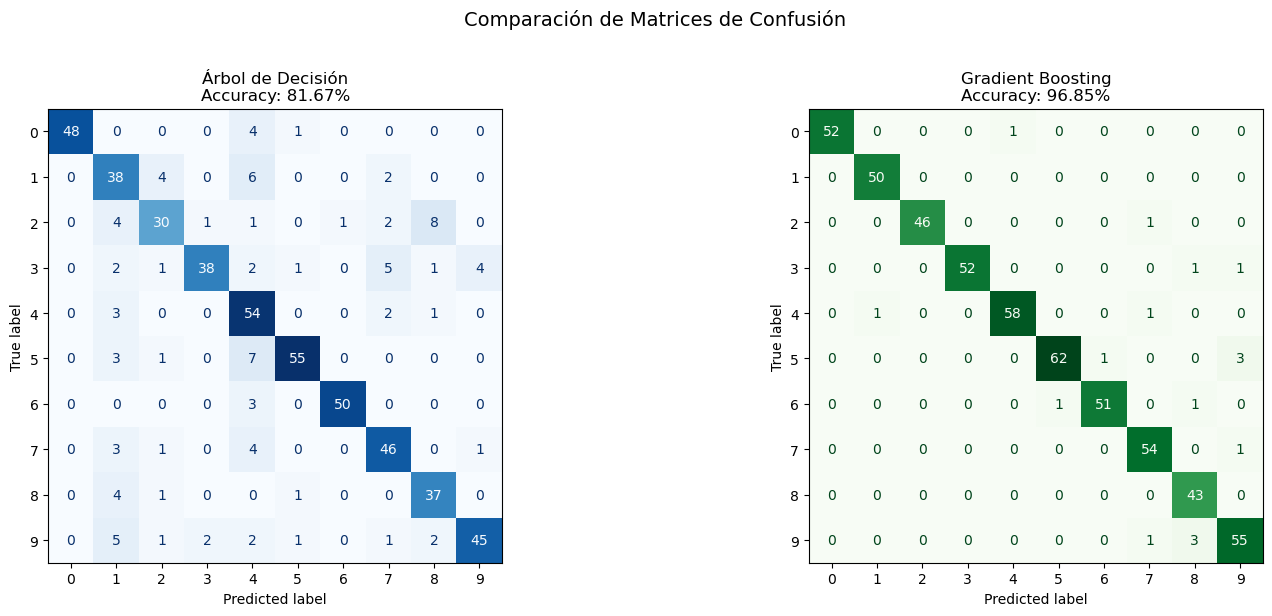


Matriz de Confusión - Gradient Boosting:
[[52  0  0  0  1  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 46  0  0  0  0  1  0  0]
 [ 0  0  0 52  0  0  0  0  1  1]
 [ 0  1  0  0 58  0  0  1  0  0]
 [ 0  0  0  0  0 62  1  0  0  3]
 [ 0  0  0  0  0  1 51  0  1  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  0  0  0 43  0]
 [ 0  0  0  0  0  0  0  1  3 55]]


In [14]:
# Calculamos la matriz de confusión de Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Visualizamos ambas matrices lado a lado para comparar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm_dt, display_labels=digits.target_names).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"Árbol de Decisión\nAccuracy: {acc_dt*100:.2f}%", fontsize=12)

ConfusionMatrixDisplay(cm_gb, display_labels=digits.target_names).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f"Gradient Boosting\nAccuracy: {acc_gb*100:.2f}%", fontsize=12)

plt.suptitle("Comparación de Matrices de Confusión", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nMatriz de Confusión - Gradient Boosting:")
print(cm_gb)

Importancia de Variables del Gradient Boosting

In [15]:
# Obtenemos la importancia de variables del Gradient Boosting
importances_gb = gb.feature_importances_

df_importances_gb = pd.DataFrame({
    'variable': feature_names,
    'importancia': importances_gb
}).sort_values('importancia', ascending=False)

print("Top 15 variables más importantes (Gradient Boosting):")
print(df_importances_gb.head(15).to_string(index=False))

Top 15 variables más importantes (Gradient Boosting):
variable  importancia
pixel_21     0.086659
pixel_42     0.085395
pixel_36     0.074718
pixel_43     0.070334
pixel_33     0.061100
pixel_60     0.055686
 pixel_5     0.048962
pixel_26     0.040423
pixel_20     0.032034
pixel_28     0.028437
pixel_19     0.028326
pixel_29     0.027055
pixel_62     0.026548
pixel_10     0.021748
pixel_46     0.021502


In [16]:
# Tabla resumen de los dos modelos
resultados = pd.DataFrame({
    'Modelo': ['Árbol de Decisión', 'Gradient Boosting'],
    'Accuracy': [f"{acc_dt*100:.2f}%", f"{acc_gb*100:.2f}%"],
    'Parámetros clave': [
        'criterion=entropy, max_depth=5',
        'n_estimators=100, max_depth=3, lr=0.1'
    ]
})
print(resultados.to_string(index=False))

           Modelo Accuracy                      Parámetros clave
Árbol de Decisión   81.67%        criterion=entropy, max_depth=5
Gradient Boosting   96.85% n_estimators=100, max_depth=3, lr=0.1


### Conclusiones

**Árbol de Decisión:**
- Es un modelo simple y fácil de interpretar (se puede visualizar)
- Aprende con un solo árbol
- Puede tener menor precisión, especialmente en problemas complejos como este (64 variables, 10 clases)

**Gradient Boosting:**
- Usa 100 árboles pequeños de forma secuencial, cada uno corrigiendo errores del anterior
- Generalmente obtiene mayor accuracy
- Es menos interpretable (no se puede visualizar fácilmente como un solo árbol)

Gradient Boosting es más poderoso para clasificar dígitos, pero a costa de mayor tiempo de entrenamiento y menor interpretabilidad. El árbol de decisión sigue siendo útil cuando necesitamos explicar cómo funciona el modelo.